In [2]:
import pandas as pd

# Let's inspect how the data is separated (UCI datasets often use semicolons ';')
try:
    df = pd.read_csv('../data/raw/student_data.csv', sep=';')
    print("✅ Successfully loaded with semicolon separator!")
except Exception as e:
    df = pd.read_csv('../data/raw/student_data.csv')
    print("✅ Loaded with default comma separator!")

# Show the first 5 rows and the columns we have
print(f"Dataset Shape: {df.shape}")
df.head()

✅ Successfully loaded with semicolon separator!
Dataset Shape: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


Target mapped: 1 for Dropout, 0 for Non-Dropout.


C:\Users\RRH\AppData\Local\Temp\ipykernel_3276\1687812833.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette='coolwarm')


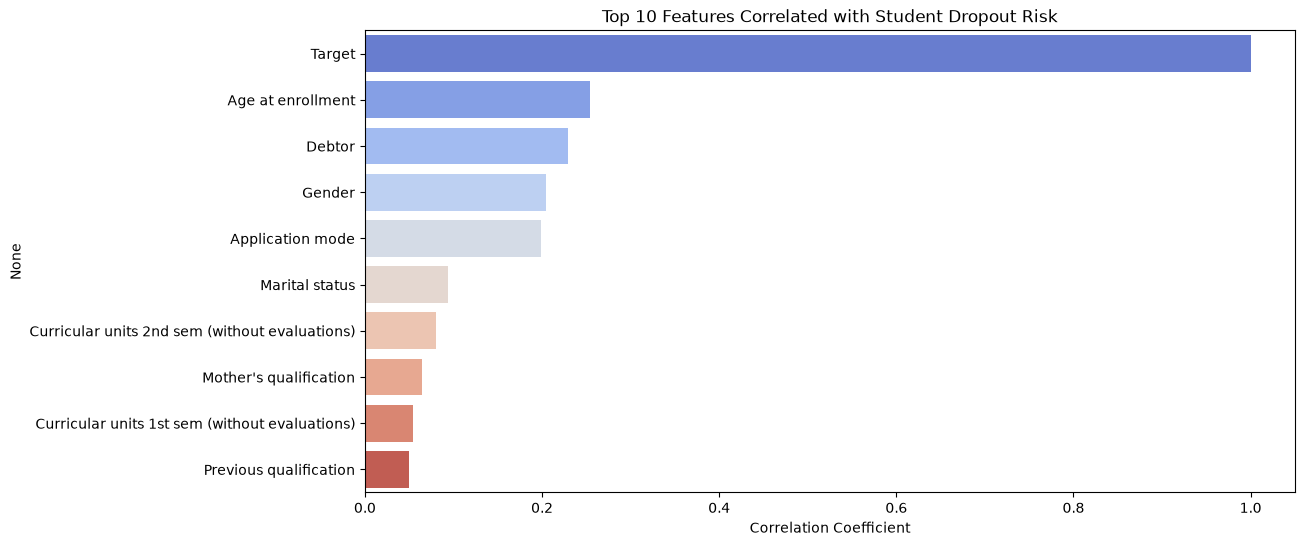

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert text target to binary numbers (1 = Dropout, 0 = Stayed/Graduated)
if 'Target' in df.columns:
    df['Target'] = df['Target'].apply(lambda x: 1 if str(x).strip() == 'Dropout' else 0)
    print("Target mapped: 1 for Dropout, 0 for Non-Dropout.")
else:
    # If columns have underscores like 'Target_Variable'
    print("Columns available:", df.columns)

# Plot the top correlations
plt.figure(figsize=(12, 6))
top_corr = df.corr()['Target'].sort_values(ascending=False).head(10)
sns.barplot(x=top_corr.values, y=top_corr.index, palette='coolwarm')
plt.title('Top 10 Features Correlated with Student Dropout Risk')
plt.xlabel('Correlation Coefficient')
plt.show()

In [2]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

def preprocess_and_save_production(df):
    print("✨ Starting Production Preprocessing Pipeline...")
    
    # 1. Standardize column names (stripping trailing whitespace, replacing spaces with underscores)
    df.columns = [col.strip().replace(' ', '_') for col in df.columns]
    
    # 2. Map target classes to Binary Dropout Risk
    if 'Target' in df.columns:
        df['Target'] = df['Target'].apply(lambda x: 1 if str(x).strip() == 'Dropout' else 0)
    else:
        raise KeyError("Target column missing from dataset!")
    
    # 3. Split Features and Target
    X = df.drop(columns=['Target', 'Dropout_Risk'], errors='ignore') # ignore Dropout_Risk if created in EDA steps
    y = df['Target']
    
    # 4. Explicitly isolate continuous numerical features that genuinely require scaling
    # Any feature not in this list is treated as a categorical/binary indicator
    numerical_cols = [
        'Previous_qualification_(grade)',
        'Admission_grade',
        'Age_at_enrollment',
        'Curricular_units_1st_sem_(credited)',
        'Curricular_units_1st_sem_(enrolled)',
        'Curricular_units_1st_sem_(evaluations)',
        'Curricular_units_1st_sem_(approved)',
        'Curricular_units_1st_sem_(grade)',
        'Curricular_units_1st_sem_(without_evaluations)',
        'Curricular_units_2nd_sem_(credited)',
        'Curricular_units_2nd_sem_(enrolled)',
        'Curricular_units_2nd_sem_(evaluations)',
        'Curricular_units_2nd_sem_(approved)',
        'Curricular_units_2nd_sem_(grade)',
        'Curricular_units_2nd_sem_(without_evaluations)',
        'Unemployment_rate',
        'Inflation_rate',
        'GDP'
    ]
    
    # Dynamically discover all remaining categorical/encoded columns
    categorical_cols = [col for col in X.columns if col not in numerical_cols]
    
    print(f"📊 Identified {len(numerical_cols)} numerical features for scaling.")
    print(f"🏷️ Identified {len(categorical_cols)} categorical/binary features to preserve.")
    
    # 5. 80/20 Stratified Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Ensure processed directory exists
    os.makedirs('../data/processed', exist_ok=True)
    
    # --- TRACK A: Save RAW unscaled data (XGBoost / Random Forest) ---
    X_train.to_csv('../data/processed/X_train.csv', index=False)
    X_test.to_csv('../data/processed/X_test.csv', index=False)
    
    # --- TRACK B: Scale ONLY numerical columns (Logistic Regression) ---
    # Create copies to avoid overwriting raw splits
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()
    
    scaler = StandardScaler()
    
    # Fit and transform ONLY the continuous features
    X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
    X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])
    
    # Save the correctly partitioned scaled tracks
    X_train_scaled.to_csv('../data/processed/X_train_scaled.csv', index=False)
    X_test_scaled.to_csv('../data/processed/X_test_scaled.csv', index=False)
    
    # Save Shared Targets
    y_train.to_csv('../data/processed/y_train.csv', index=False)
    y_test.to_csv('../data/processed/y_test.csv', index=False)
    
    # Save scaler artifact (it will know to only expect/transform the numerical subset later)
    os.makedirs('../models', exist_ok=True)
    joblib.dump(scaler, '../models/scaler.pkl')
    
    print("✅ Preprocessing complete! Outputs successfully generated with isolated scaling tracks.")
# --- REPLACE THE VERY BOTTOM OF YOUR CELL WITH THIS ---

# 1. Load the data fresh right inside this cell so Jupyter never throws a NameError again!
df = pd.read_csv('../data/raw/student_data.csv', sep=';')

# 2. Execute the updated pipeline function
preprocess_and_save_production(df)

✨ Starting Production Preprocessing Pipeline...
📊 Identified 18 numerical features for scaling.
🏷️ Identified 18 categorical/binary features to preserve.
✅ Preprocessing complete! Outputs successfully generated with isolated scaling tracks.
